In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, precision_recall_curve, auc
)
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers
from tensorflow.keras.utils import to_categorical

In [8]:
# Load data
train_standard_df = pd.read_csv('./train_standard.csv')
test_standard_df = pd.read_csv('./test_standard.csv')
train_minmax_df = pd.read_csv('./train_minmax.csv')
test_minmax_df = pd.read_csv('./test_minmax.csv')


In [9]:
# Separate features and target for both standard and minmax datasets
X_train_standard = train_standard_df.drop(columns=['target'])
y_train_standard = train_standard_df['target']
X_test_standard = test_standard_df.drop(columns=['target'])
y_test_standard = test_standard_df['target']

X_train_minmax = train_minmax_df.drop(columns=['target'])
y_train_minmax = train_minmax_df['target']
X_test_minmax = test_minmax_df.drop(columns=['target'])
y_test_minmax = test_minmax_df['target']


In [10]:
# Updated evaluate_model function to return metrics
def evaluate_model(y_true, y_pred, y_proba=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=1),
        "recall": recall_score(y_true, y_pred, zero_division=1),
        "f1_score": f1_score(y_true, y_pred, zero_division=1)
    }
    if y_proba is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, y_proba)
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        metrics["auprc"] = auc(recall, precision)
    
    # Print individual metrics for the fold
    for key, value in metrics.items():
        print(f"{key.capitalize()}: {value:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()
    
    return metrics

In [11]:
# Logistic Regression Model with Cross-Validation (Full Metrics for Each Fold)
def logistic_regression_cv(X, y):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold = 1
    all_metrics = []

    for train_index, val_index in cv.split(X, y):
        print(f"\nTraining on Fold {fold}")
        X_train_cv, X_val_cv = X.iloc[train_index], X.iloc[val_index]
        y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]

        model = LogisticRegression(class_weight='balanced')
        model.fit(X_train_cv, y_train_cv)

        # Predictions and Evaluation for the current fold
        y_pred = model.predict(X_val_cv)
        y_proba = model.predict_proba(X_val_cv)[:, 1]  # Probability of positive class
        print(f"Fold {fold} Metrics:")
        fold_metrics = evaluate_model(y_val_cv, y_pred, y_proba)
        all_metrics.append(fold_metrics)

        fold += 1

    # Calculate and print average metrics across all folds
    avg_metrics = {metric: np.mean([fold_metrics[metric] for fold_metrics in all_metrics]) for metric in all_metrics[0]}
    print("\nAverage Metrics Across All Folds for Logistic Regression:")
    for key, value in avg_metrics.items():
        print(f"{key.capitalize()}: {value:.4f}")


In [12]:
# Feedforward Neural Network Model with Cross-Validation (Full Metrics for Each Fold)
def fnn_cv(X, y, input_dim):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold = 1
    all_metrics = []

    for train_index, val_index in cv.split(X, y):
        print(f"\nTraining on Fold {fold}")
        X_train_cv, X_val_cv = X[train_index], X[val_index]
        y_train_cv, y_val_cv = y[train_index], y[val_index]

        # One-hot encoding for binary classification (if target is binary 0/1)
        y_train_cat = to_categorical(y_train_cv, num_classes=2)
        y_val_cat = to_categorical(y_val_cv, num_classes=2)

        # Define the model
        model = models.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(64, activation='relu'),
            layers.Dense(32, activation='relu'),
            layers.Dense(2, activation='softmax')  # Output layer for binary classification
        ])

        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        # Train the model
        model.fit(X_train_cv, y_train_cat, epochs=10, batch_size=32, verbose=0)

        # Predictions and Evaluation for the current fold
        y_pred = np.argmax(model.predict(X_val_cv), axis=1)
        y_proba = model.predict(X_val_cv)[:, 1]  # Probability of positive class
        print(f"Fold {fold} Metrics:")
        fold_metrics = evaluate_model(y_val_cv, y_pred, y_proba)
        all_metrics.append(fold_metrics)
        
        # Analyze prediction distribution
        unique, counts = np.unique(y_pred, return_counts=True)
        print("Prediction distribution:", dict(zip(unique, counts)))

        fold += 1

    # Calculate and print average metrics across all folds
    avg_metrics = {metric: np.mean([fold_metrics[metric] for fold_metrics in all_metrics]) for metric in all_metrics[0]}
    print("\nAverage Metrics Across All Folds for FNN:")
    for key, value in avg_metrics.items():
        print(f"{key.capitalize()}: {value:.4f}")


Standard Scaled Data - Logistic Regression Cross-Validation:

Training on Fold 1
Fold 1 Metrics:
Accuracy: 0.7570
Precision: 0.2091
Recall: 0.7188
F1_score: 0.3239
Roc_auc: 0.8123
Auprc: 0.3479


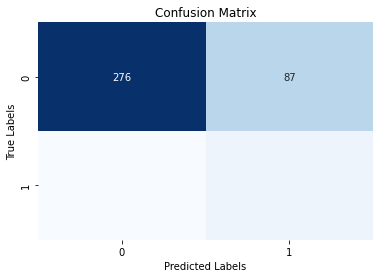


Training on Fold 2
Fold 2 Metrics:
Accuracy: 0.7519
Precision: 0.2054
Recall: 0.7188
F1_score: 0.3194
Roc_auc: 0.8407
Auprc: 0.3089


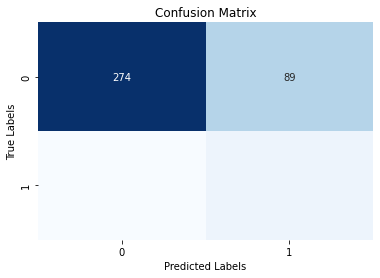


Training on Fold 3
Fold 3 Metrics:
Accuracy: 0.7696
Precision: 0.2294
Recall: 0.7812
F1_score: 0.3546
Roc_auc: 0.8484
Auprc: 0.3112


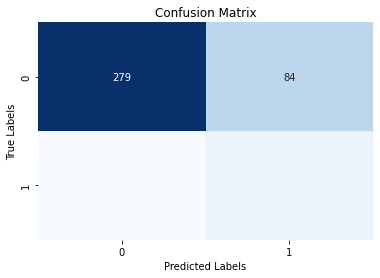


Training on Fold 4
Fold 4 Metrics:
Accuracy: 0.7595
Precision: 0.2308
Recall: 0.8438
F1_score: 0.3624
Roc_auc: 0.8295
Auprc: 0.3664


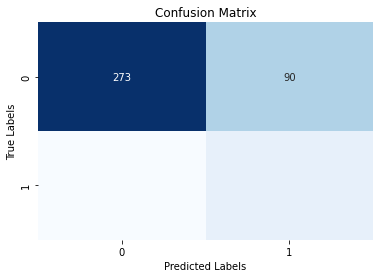


Training on Fold 5
Fold 5 Metrics:
Accuracy: 0.7696
Precision: 0.1959
Recall: 0.5938
F1_score: 0.2946
Roc_auc: 0.7639
Auprc: 0.2296


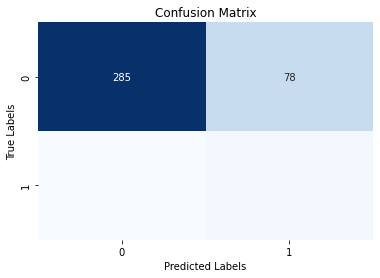


Average Metrics Across All Folds for Logistic Regression:
Accuracy: 0.7615
Precision: 0.2141
Recall: 0.7312
F1_score: 0.3310
Roc_auc: 0.8190
Auprc: 0.3128

Standard Scaled Data - FNN Cross-Validation:

Training on Fold 1


2024-11-13 16:53:22.309288: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2024-11-13 16:53:22.309319: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2024-11-13 16:53:22.309329: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2024-11-13 16:53:22.309351: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-11-13 16:53:22.309373: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2024-11-13 16:53:23.895374: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 1 Metrics:
Accuracy: 0.9215
Precision: 0.6000
Recall: 0.0938
F1_score: 0.1622
Roc_auc: 0.8075
Auprc: 0.3226


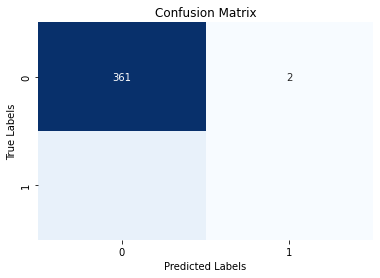

Prediction distribution: {0: 390, 1: 5}

Training on Fold 2
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Fold 2 Metrics:
Accuracy: 0.9266
Precision: 0.6667
Recall: 0.1875
F1_score: 0.2927
Roc_auc: 0.8333
Auprc: 0.3870


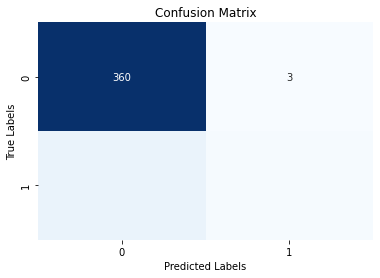

Prediction distribution: {0: 386, 1: 9}

Training on Fold 3
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Fold 3 Metrics:
Accuracy: 0.9114
Precision: 0.3333
Recall: 0.0938
F1_score: 0.1463
Roc_auc: 0.8429
Auprc: 0.3191


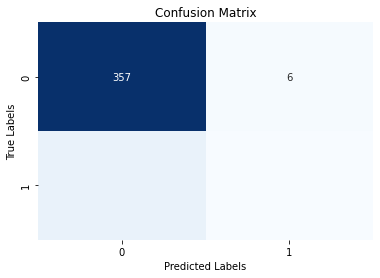

Prediction distribution: {0: 386, 1: 9}

Training on Fold 4
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Fold 4 Metrics:
Accuracy: 0.9190
Precision: 0.5000
Recall: 0.2188
F1_score: 0.3043
Roc_auc: 0.8127
Auprc: 0.3339


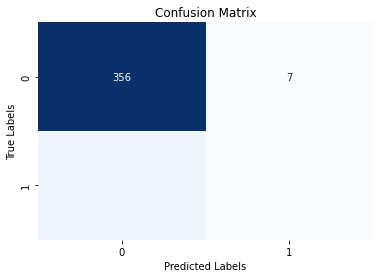

Prediction distribution: {0: 381, 1: 14}

Training on Fold 5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Fold 5 Metrics:
Accuracy: 0.9165
Precision: 0.3333
Recall: 0.0312
F1_score: 0.0571
Roc_auc: 0.7572
Auprc: 0.1965


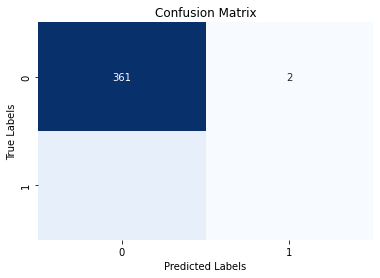

Prediction distribution: {0: 392, 1: 3}

Average Metrics Across All Folds for FNN:
Accuracy: 0.9190
Precision: 0.4867
Recall: 0.1250
F1_score: 0.1925
Roc_auc: 0.8107
Auprc: 0.3118


In [13]:
# Running cross-validation on Standard Scaled data
print("Standard Scaled Data - Logistic Regression Cross-Validation:")
logistic_regression_cv(X_train_standard, y_train_standard)
print("\nStandard Scaled Data - FNN Cross-Validation:")
fnn_cv(X_train_standard.values, y_train_standard.values, input_dim=X_train_standard.shape[1])



MinMax Scaled Data - Logistic Regression Cross-Validation:

Training on Fold 1
Fold 1 Metrics:
Accuracy: 0.7468
Precision: 0.1964
Recall: 0.6875
F1_score: 0.3056
Roc_auc: 0.8088
Auprc: 0.3375


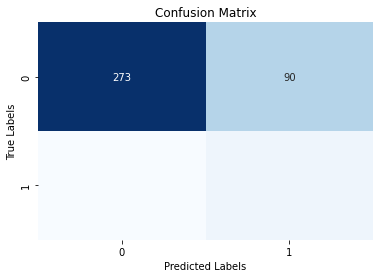


Training on Fold 2
Fold 2 Metrics:
Accuracy: 0.7418
Precision: 0.2083
Recall: 0.7812
F1_score: 0.3289
Roc_auc: 0.8424
Auprc: 0.3020


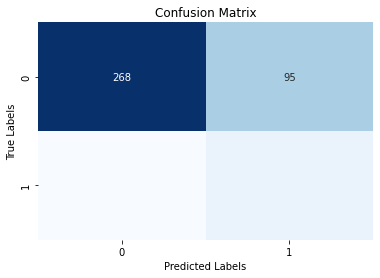


Training on Fold 3
Fold 3 Metrics:
Accuracy: 0.7646
Precision: 0.2437
Recall: 0.9062
F1_score: 0.3841
Roc_auc: 0.8623
Auprc: 0.3157


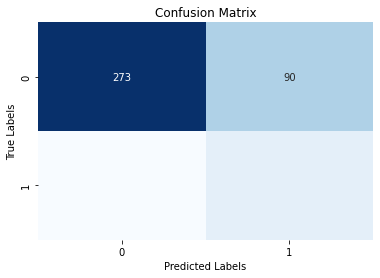


Training on Fold 4
Fold 4 Metrics:
Accuracy: 0.7544
Precision: 0.2222
Recall: 0.8125
F1_score: 0.3490
Roc_auc: 0.8279
Auprc: 0.3404


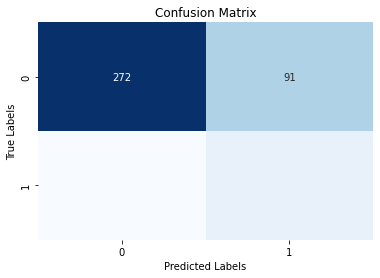


Training on Fold 5
Fold 5 Metrics:
Accuracy: 0.7570
Precision: 0.1863
Recall: 0.5938
F1_score: 0.2836
Roc_auc: 0.7821
Auprc: 0.2388


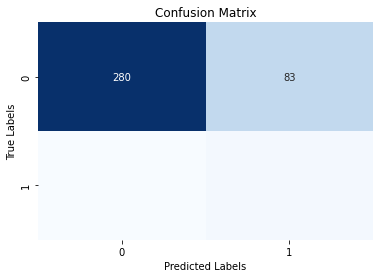


Average Metrics Across All Folds for Logistic Regression:
Accuracy: 0.7529
Precision: 0.2114
Recall: 0.7562
F1_score: 0.3302
Roc_auc: 0.8247
Auprc: 0.3069

MinMax Scaled Data - FNN Cross-Validation:

Training on Fold 1
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 1 Metrics:
Accuracy: 0.9215
Precision: 1.0000
Recall: 0.0312
F1_score: 0.0606
Roc_auc: 0.7751
Auprc: 0.2552


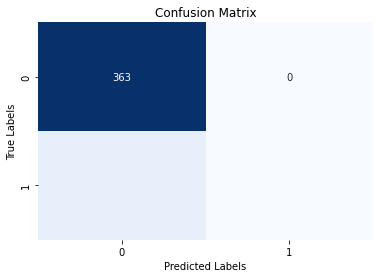

Prediction distribution: {0: 394, 1: 1}

Training on Fold 2
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 2 Metrics:
Accuracy: 0.9190
Precision: 1.0000
Recall: 0.0000
F1_score: 0.0000
Roc_auc: 0.7936
Auprc: 0.2421


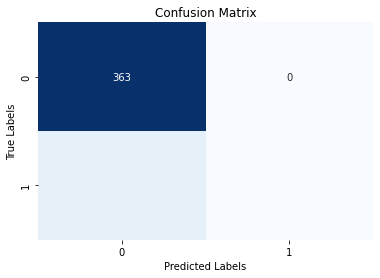

Prediction distribution: {0: 395}

Training on Fold 3
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 3 Metrics:
Accuracy: 0.9190
Precision: 1.0000
Recall: 0.0000
F1_score: 0.0000
Roc_auc: 0.8153
Auprc: 0.2988


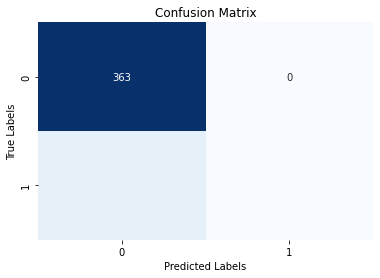

Prediction distribution: {0: 395}

Training on Fold 4
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Fold 4 Metrics:
Accuracy: 0.9190
Precision: 0.5000
Recall: 0.0312
F1_score: 0.0588
Roc_auc: 0.7925
Auprc: 0.2555


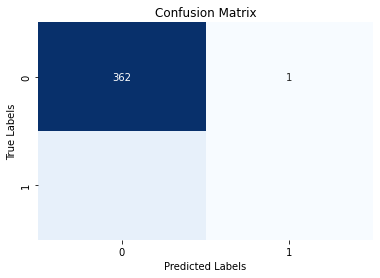

Prediction distribution: {0: 393, 1: 2}

Training on Fold 5
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Fold 5 Metrics:
Accuracy: 0.9190
Precision: 1.0000
Recall: 0.0000
F1_score: 0.0000
Roc_auc: 0.7748
Auprc: 0.2038


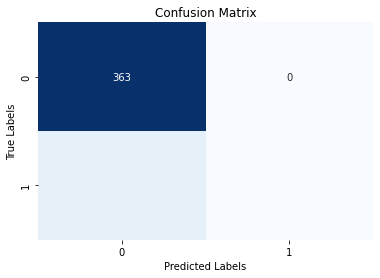

Prediction distribution: {0: 395}

Average Metrics Across All Folds for FNN:
Accuracy: 0.9195
Precision: 0.9000
Recall: 0.0125
F1_score: 0.0239
Roc_auc: 0.7903
Auprc: 0.2511


In [14]:
# Running cross-validation on MinMax Scaled data
print("\nMinMax Scaled Data - Logistic Regression Cross-Validation:")
logistic_regression_cv(X_train_minmax, y_train_minmax)
print("\nMinMax Scaled Data - FNN Cross-Validation:")
fnn_cv(X_train_minmax.values, y_train_minmax.values, input_dim=X_train_minmax.shape[1])
